In [2]:
#Librerías utilizadas
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
#carga de data set
df= pd.read_csv("datos.csv")

In [4]:
#Tipos de datos de cada columna
df.dtypes

Sistema                                     object
Area                                        object
Generacion (MWh)                           float64
Importacion Total (MWh)                    float64
Exportacion Total (MWh)                    float64
Intercambio neto entre Gerencias (MWh)      object
Estimacion de Demanda por Balance (MWh)    float64
Pronostico (MWh)                           float64
Timestamp                                   object
dtype: object

In [5]:
#Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373768 entries, 0 to 373767
Data columns (total 9 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Sistema                                  373768 non-null  object 
 1   Area                                     373768 non-null  object 
 2   Generacion (MWh)                         373768 non-null  float64
 3   Importacion Total (MWh)                  373768 non-null  float64
 4   Exportacion Total (MWh)                  373768 non-null  float64
 5   Intercambio neto entre Gerencias (MWh)   373768 non-null  object 
 6   Estimacion de Demanda por Balance (MWh)  373768 non-null  float64
 7   Pronostico (MWh)                         373768 non-null  float64
 8   Timestamp                                373768 non-null  object 
dtypes: float64(5), object(4)
memory usage: 25.7+ MB


In [6]:
#Dimensiones del DataFrame
df.shape

(373768, 9)

In [7]:
#Columnas del DataFrame
df.columns

Index(['Sistema', 'Area', 'Generacion (MWh)', 'Importacion Total (MWh)',
       'Exportacion Total (MWh)', 'Intercambio neto entre Gerencias (MWh)',
       'Estimacion de Demanda por Balance (MWh)', 'Pronostico (MWh)',
       'Timestamp'],
      dtype='object')

In [8]:
#Imprimir los primeros 10 registros de la base
df.head(10)

,Sistema,Area,Generacion (MWh),Importacion Total (MWh),Exportacion Total (MWh),Intercambio neto entre Gerencias (MWh),Estimacion de Demanda por Balance (MWh),Pronostico (MWh),Timestamp
0,BCA,BCA,1124.16477,121.97846,220.99560,---,1025.14763,1006.009,01/01/2020 00:00
1,BCA,BCA,1053.94972,83.21267,131.53384,---,1005.62855,979.489,01/01/2020 01:00
2,BCA,BCA,1047.20819,107.04241,172.11608,---,982.13452,955.624,01/01/2020 02:00
3,BCA,BCA,1042.45775,115.12048,197.85693,---,959.72130,926.639,01/01/2020 03:00
4,BCA,BCA,1026.56176,114.05929,198.96707,---,941.65398,904.216,01/01/2020 04:00
5,BCA,BCA,1039.22818,94.75696,205.94005,---,928.04509,892.401,01/01/2020 05:00
6,BCA,BCA,1024.73395,84.69250,206.23433,---,903.19212,873.014,01/01/2020 06:00
7,BCA,BCA,1036.62413,75.03556,244.05527,---,867.60442,841.099,01/01/2020 07:00
8,BCA,BCA,1021.09310,28.88269,175.23318,---,874.74261,863.128,01/01/2020 08:00
9,BCA,BCA,993.90340,66.16441,169.13380,---,890.93401,891.546,01/01/2020 09:00


In [9]:
#imprimir los últimos 10 registros de la base
df.tail(10)

,Sistema,Area,Generacion (MWh),Importacion Total (MWh),Exportacion Total (MWh),Intercambio neto entre Gerencias (MWh),Estimacion de Demanda por Balance (MWh),Pronostico (MWh),Timestamp
373758,SIN,PEN,1762.89794,0.0,53.57490,325.125,2034.44804,2177.411,30/09/2024 14:00
373759,SIN,PEN,1703.58597,0.0,53.60848,432.213,2082.19049,2247.555,30/09/2024 15:00
373760,SIN,PEN,1644.61503,0.0,53.82255,502.324,2093.11648,2269.859,30/09/2024 16:00
373761,SIN,PEN,1654.02233,0.0,53.55617,497.523,2097.98916,2249.865,30/09/2024 17:00
373762,SIN,PEN,1695.32956,0.0,54.02527,521.261,2162.56529,2342.959,30/09/2024 18:00
373763,SIN,PEN,1690.08687,0.0,54.47620,530.824,2166.43467,2413.661,30/09/2024 19:00
373764,SIN,PEN,1626.89274,0.0,53.88127,593.09,2166.10147,2460.071,30/09/2024 20:00
373765,SIN,PEN,1627.05534,0.0,54.37937,612.584,2185.25997,2512.388,30/09/2024 21:00
373766,SIN,PEN,1585.77332,0.0,53.82536,646.254,2178.20197,2491.674,30/09/2024 22:00
373767,SIN,PEN,1552.78983,0.0,54.13863,639.645,2138.29620,2420.197,30/09/2024 23:00


In [10]:
#Convertir la columna "fecha" a tipo datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True)
df.dtypes

Sistema                                            object
Area                                               object
Generacion (MWh)                                  float64
Importacion Total (MWh)                           float64
Exportacion Total (MWh)                           float64
Intercambio neto entre Gerencias (MWh)             object
Estimacion de Demanda por Balance (MWh)           float64
Pronostico (MWh)                                  float64
Timestamp                                  datetime64[ns]
dtype: object

In [11]:
#Función para imprimir un resumen estadístico de las columnas numéricas del DataFrame
#Se crea un dataframe para guardar el resumen estadístico
#La función recibe como parámetros el DataFrame y una lista con los nombres de las columnas numéricas a analizar
#Se itera sobre las columnas y se calcula el resumen estadístico para cada una
#Se devuelve un DataFrame con el resumen estadístico 
def resumen_estadistico(df, columnas):
    resumen = pd.DataFrame()

    for col in columnas:
        serie = df[col].dropna()  

        resumen[col] = pd.Series({
            'Observaciones': len(serie),
            'Media': serie.mean(),
            'Desviación Std': serie.std(),
            'Mínimo': serie.min(),
            'Q1 (25%)': serie.quantile(0.25),
            'Mediana (Q2)': serie.median(),
            'Q3 (75%)': serie.quantile(0.75),
            'Máximo': serie.max(),
            'Rango (Max-Min)': serie.max() - serie.min(),
            'Moda': serie.mode().iloc[0] if not serie.mode().empty else None
        })

    return resumen.T

In [12]:
columnas_numericas = [
    "Generacion (MWh)",
    "Importacion Total (MWh)",
    "Exportacion Total (MWh)",
    "Estimacion de Demanda por Balance (MWh)",
    "Pronostico (MWh)"
]

In [13]:
resumen_estadistico(df, columnas_numericas)

,Observaciones,Media,Desviación Std,Mínimo,Q1 (25%),Mediana (Q2),Q3 (75%),Máximo,Rango (Max-Min),Moda
Generacion (MWh),373768.0,4233.270784,3230.271586,108.12993,1492.845863,3572.183925,6114.695265,14531.51662,14423.38669,187.99233
Importacion Total (MWh),373768.0,25.926315,81.064669,0.00000,0.000000,0.000000,0.001490,979.74679,979.74679,0.00000
Exportacion Total (MWh),373768.0,33.945439,65.570909,0.00000,0.000000,0.000000,44.536145,758.06034,758.06034,0.00000
Estimacion de Demanda por Balance (MWh),373768.0,4225.251660,2742.205173,108.12993,1774.671003,3908.345405,6548.176903,13478.30891,13370.17898,187.99233
Pronostico (MWh),373768.0,4325.747534,2830.681396,130.69500,1793.062750,3959.275000,6762.821000,12133.87300,12003.17800,249.33800


In [14]:
#Función para identificar la cantidad y porcentaje de valores nulos en cada columna del DataFrame
#La función recibe como parámetro el DataFrame
#Se calcula el total y porcentaje de valores nulos por columna
#Se crea un DataFrame con el resumen
#Se devuelve un DataFrame con el resumen de valores nulos ordenado por porcentaje descendente
def resumen_nulos(df):
    total_nulos = df.isnull().sum()
    porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

    resumen = pd.DataFrame({
        'Valores Nulos': total_nulos,
        'Porcentaje Nulos (%)': porcentaje_nulos
    })

    return resumen.sort_values(by='Porcentaje Nulos (%)', ascending=False)

In [15]:
#aplicación de la función para obtener el resumen de valores nulos
resumen_nulos(df)

,Valores Nulos,Porcentaje Nulos (%)
Sistema,0,0.0
Area,0,0.0
Generacion (MWh),0,0.0
Importacion Total (MWh),0,0.0
Exportacion Total (MWh),0,0.0
Intercambio neto entre Gerencias (MWh),0,0.0
Estimacion de Demanda por Balance (MWh),0,0.0
Pronostico (MWh),0,0.0
Timestamp,0,0.0


In [16]:
# Cálcular el total de filas duplicadas
duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")

Cantidad de filas duplicadas: 0


In [17]:
#Esta función recibe el dataframe, la columna que se quiere graficar en un boxplot y en un hitograma
#para visualizar la distribución de los datos y detectar posibles valores atípicos
def graficar_distribucion(df, columna):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histograma
    axes[0].hist(df[columna].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot
    axes[1].boxplot(df[columna].dropna())
    axes[1].set_ylabel(columna)
    
    plt.tight_layout()
    plt.show()

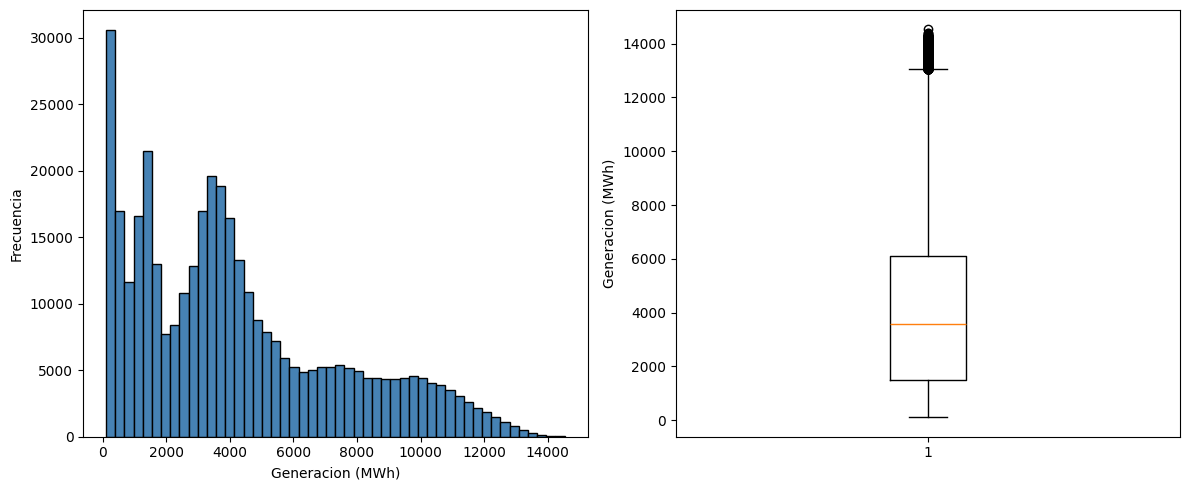

In [ ]:
#Generacion (MWh)
graficar_distribucion(df, 'Generacion (MWh)') 

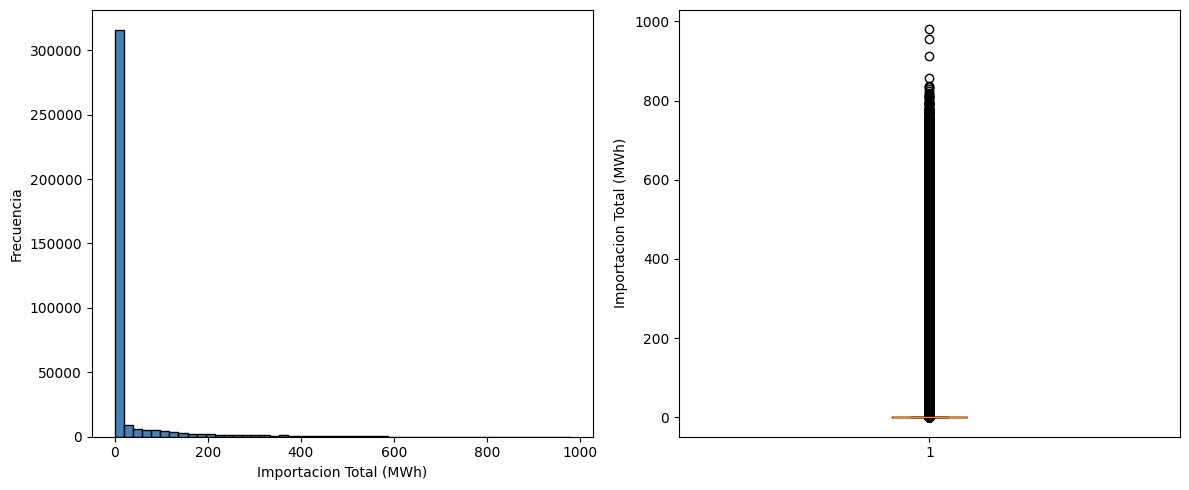

In [19]:
#Importacion Total (MWh)
graficar_distribucion(df, 'Importacion Total (MWh)') 

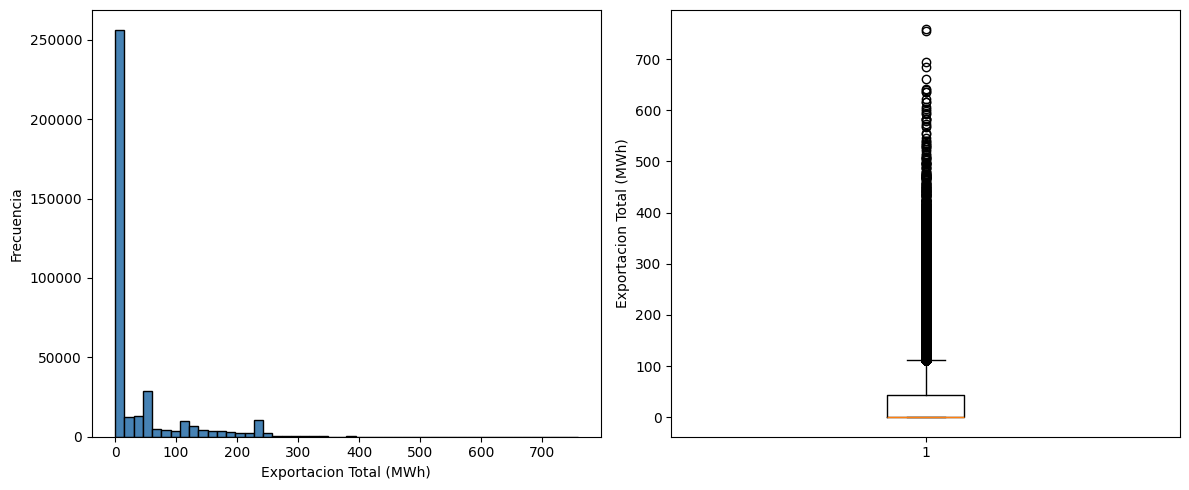

In [20]:
#Exportacion Total (MWh)
graficar_distribucion(df, 'Exportacion Total (MWh)') 

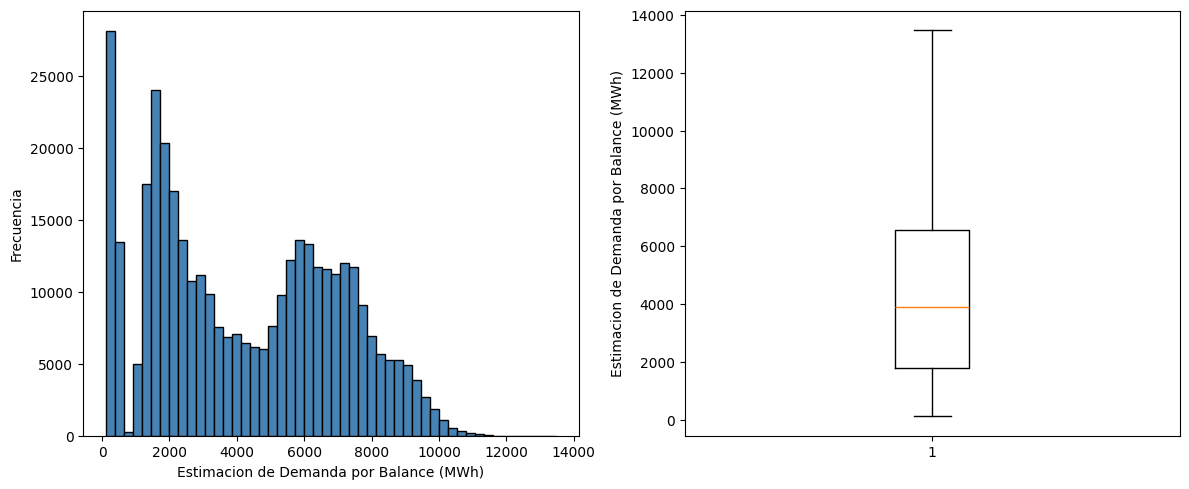

In [ ]:
#Estimacion de Demanda por Balance (MWh)
graficar_distribucion(df, 'Estimacion de Demanda por Balance (MWh)') 

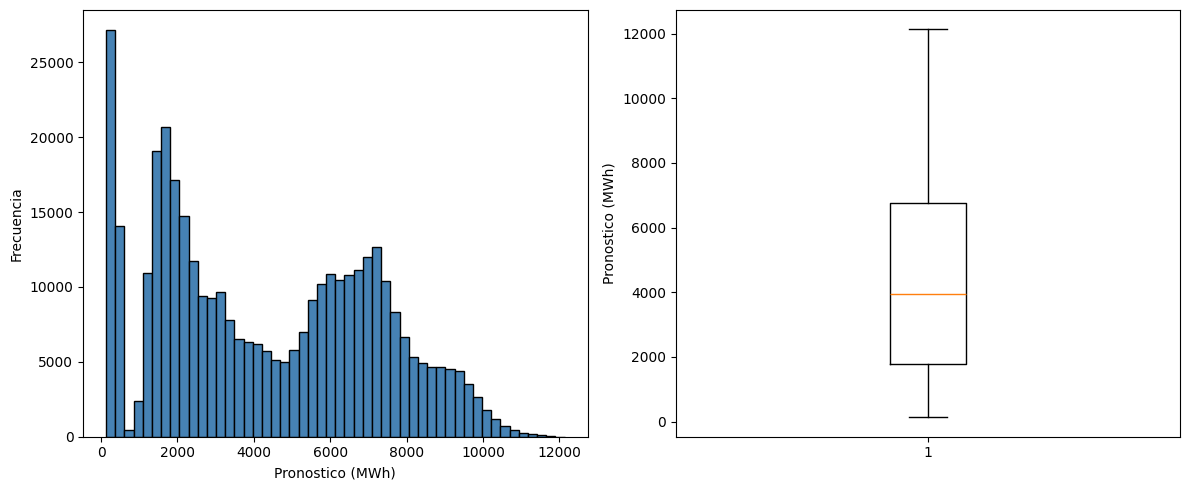

In [22]:
#Pronostico (MWh)
graficar_distribucion(df, 'Pronostico (MWh)') 

In [24]:
df

,Sistema,Area,Generacion (MWh),Importacion Total (MWh),Exportacion Total (MWh),Intercambio neto entre Gerencias (MWh),Estimacion de Demanda por Balance (MWh),Pronostico (MWh),Timestamp
0,BCA,BCA,1124.16477,121.97846,220.99560,---,1025.14763,1006.009,2020-01-01 00:00:00
1,BCA,BCA,1053.94972,83.21267,131.53384,---,1005.62855,979.489,2020-01-01 01:00:00
2,BCA,BCA,1047.20819,107.04241,172.11608,---,982.13452,955.624,2020-01-01 02:00:00
3,BCA,BCA,1042.45775,115.12048,197.85693,---,959.72130,926.639,2020-01-01 03:00:00
4,BCA,BCA,1026.56176,114.05929,198.96707,---,941.65398,904.216,2020-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...
373763,SIN,PEN,1690.08687,0.00000,54.47620,530.824,2166.43467,2413.661,2024-09-30 19:00:00
373764,SIN,PEN,1626.89274,0.00000,53.88127,593.09,2166.10147,2460.071,2024-09-30 20:00:00
373765,SIN,PEN,1627.05534,0.00000,54.37937,612.584,2185.25997,2512.388,2024-09-30 21:00:00
373766,SIN,PEN,1585.77332,0.00000,53.82536,646.254,2178.20197,2491.674,2024-09-30 22:00:00


In [25]:
#creación columna fecha
df["fecha"] = df["Timestamp"].dt.date

In [26]:
#creación columna hora 
df["hora"] = df["Timestamp"].dt.hour

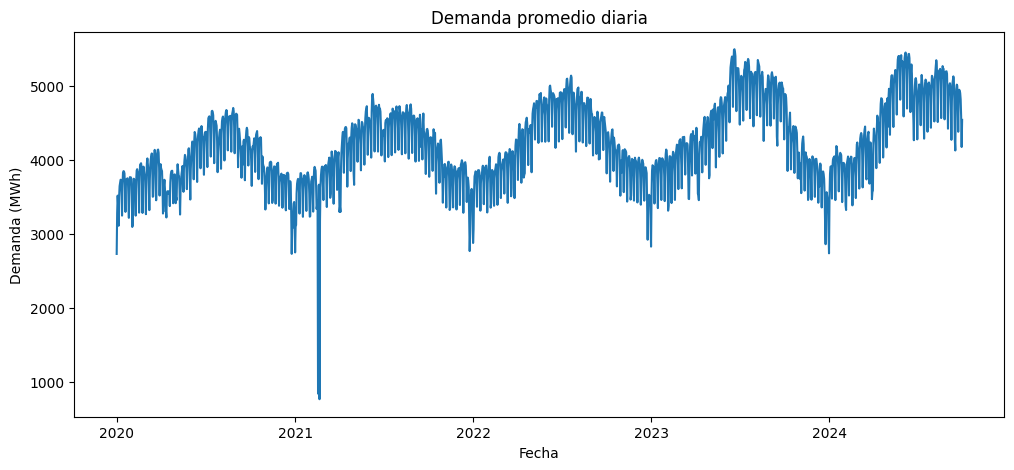

In [27]:
demanda_dia = df.groupby("fecha")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(12,5))
demanda_dia.plot()

plt.title("Demanda promedio diaria")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")
plt.show()

In [28]:
df["anio"] = df["Timestamp"].dt.year
df["mes"] = df["Timestamp"].dt.month
df["dia_semana"] = df["Timestamp"].dt.day_name()

In [29]:
df.head()

,Sistema,Area,Generacion (MWh),Importacion Total (MWh),Exportacion Total (MWh),Intercambio neto entre Gerencias (MWh),Estimacion de Demanda por Balance (MWh),Pronostico (MWh),Timestamp,fecha,hora,anio,mes,dia_semana
0,BCA,BCA,1124.16477,121.97846,220.99560,---,1025.14763,1006.009,2020-01-01 00:00:00,2020-01-01,0,2020,1,Wednesday
1,BCA,BCA,1053.94972,83.21267,131.53384,---,1005.62855,979.489,2020-01-01 01:00:00,2020-01-01,1,2020,1,Wednesday
2,BCA,BCA,1047.20819,107.04241,172.11608,---,982.13452,955.624,2020-01-01 02:00:00,2020-01-01,2,2020,1,Wednesday
3,BCA,BCA,1042.45775,115.12048,197.85693,---,959.72130,926.639,2020-01-01 03:00:00,2020-01-01,3,2020,1,Wednesday
4,BCA,BCA,1026.56176,114.05929,198.96707,---,941.65398,904.216,2020-01-01 04:00:00,2020-01-01,4,2020,1,Wednesday


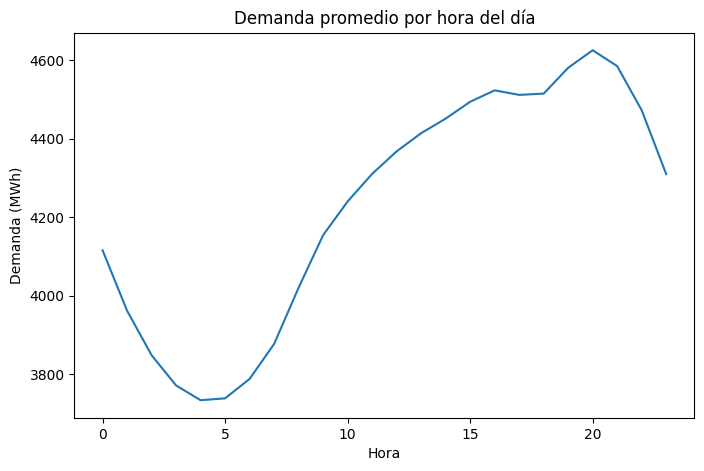

In [30]:
demanda_hora = df.groupby("hora")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(8,5))
demanda_hora.plot()

plt.title("Demanda promedio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Demanda (MWh)")
plt.show()

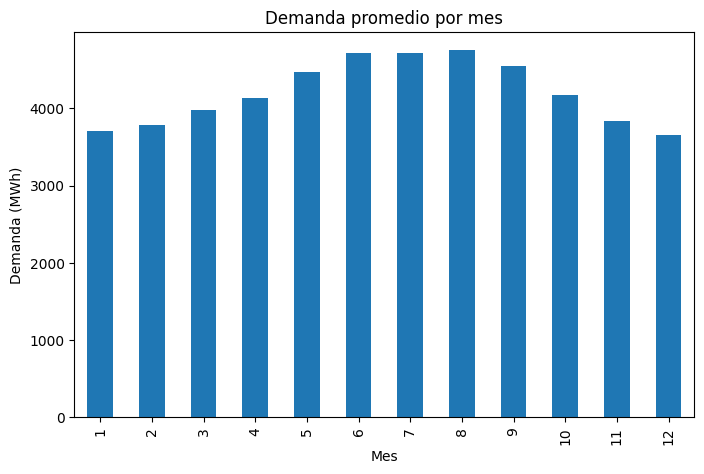

In [31]:
demanda_mes = df.groupby("mes")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(8,5))
demanda_mes.plot(kind="bar")

plt.title("Demanda promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Demanda (MWh)")
plt.show()

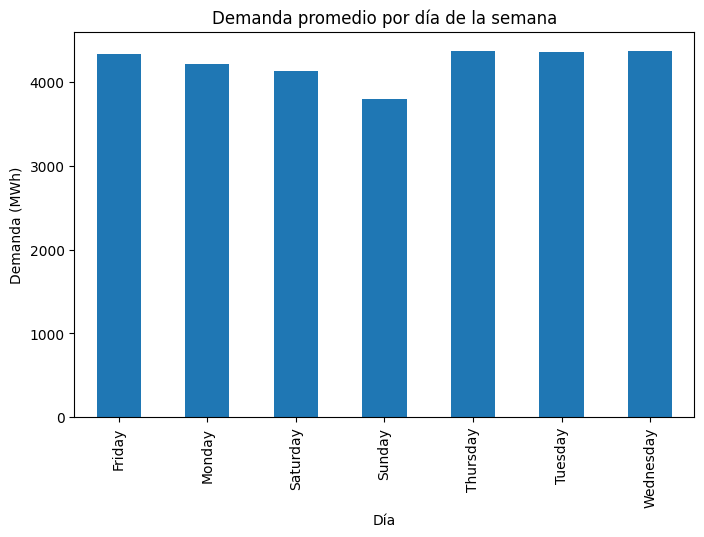

In [32]:
demanda_semana = df.groupby("dia_semana")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(8,5))
demanda_semana.plot(kind="bar")

plt.title("Demanda promedio por día de la semana")
plt.xlabel("Día")
plt.ylabel("Demanda (MWh)")
plt.show()

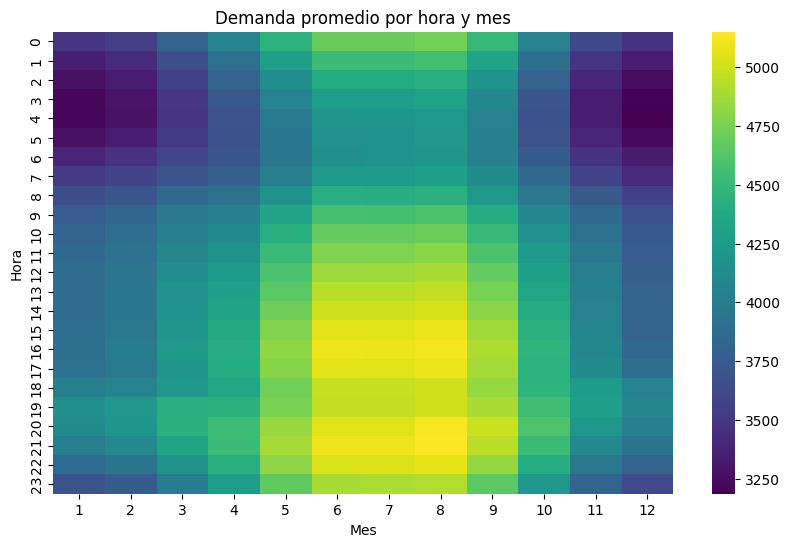

In [33]:
tabla = df.pivot_table(
    values="Estimacion de Demanda por Balance (MWh)",
    index="hora",
    columns="mes",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(tabla, cmap="viridis")

plt.title("Demanda promedio por hora y mes")
plt.xlabel("Mes")
plt.ylabel("Hora")
plt.show()

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


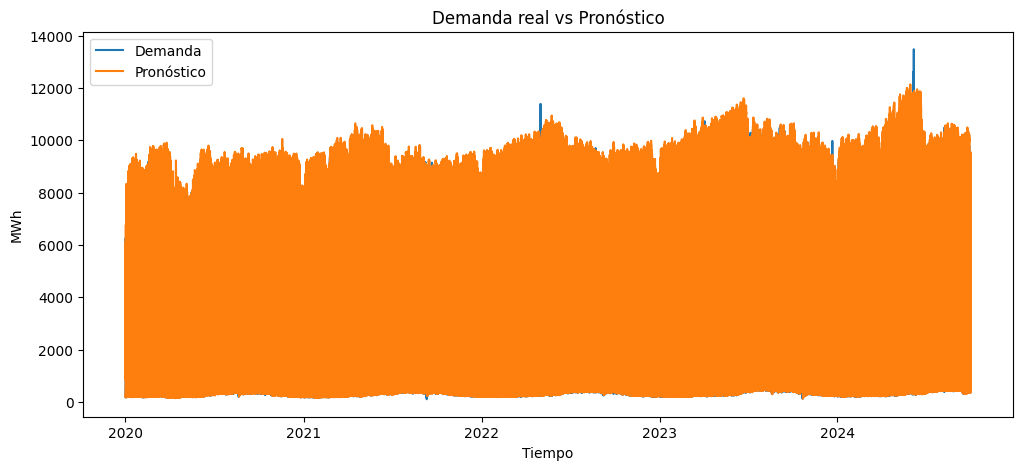

In [34]:
plt.figure(figsize=(12,5))

plt.plot(df["Timestamp"], df["Estimacion de Demanda por Balance (MWh)"], label="Demanda")
plt.plot(df["Timestamp"], df["Pronostico (MWh)"], label="Pronóstico")

plt.legend()
plt.title("Demanda real vs Pronóstico")
plt.xlabel("Tiempo")
plt.ylabel("MWh")
plt.show()

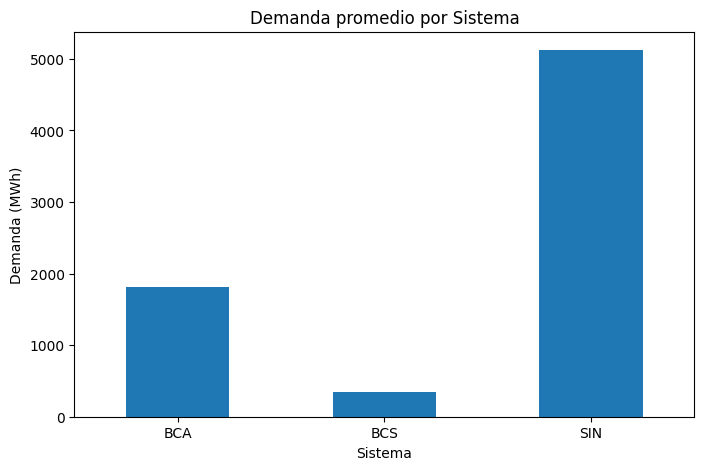

In [35]:
demanda_sistema = df.groupby("Sistema")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(8,5))
demanda_sistema.plot(kind="bar")

plt.title("Demanda promedio por Sistema")
plt.xlabel("Sistema")
plt.ylabel("Demanda (MWh)")
plt.xticks(rotation=0)

plt.show()

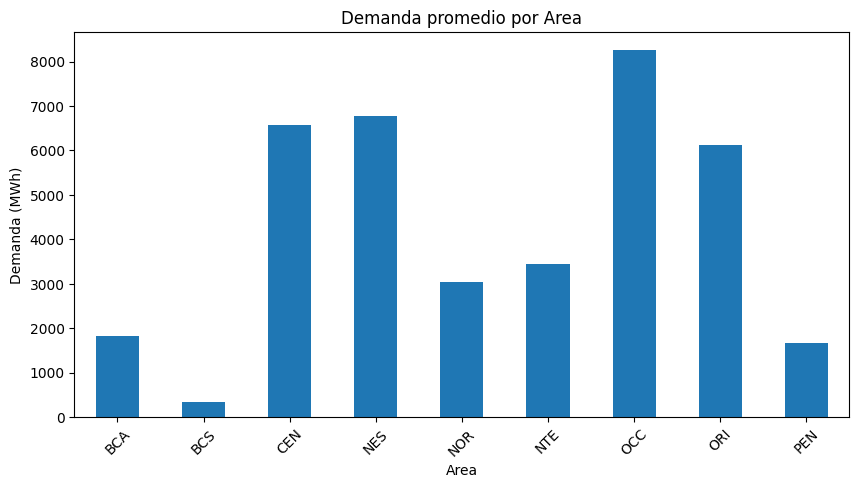

In [36]:
demanda_area = df.groupby("Area")["Estimacion de Demanda por Balance (MWh)"].mean()

plt.figure(figsize=(10,5))
demanda_area.plot(kind="bar")

plt.title("Demanda promedio por Area")
plt.xlabel("Area")
plt.ylabel("Demanda (MWh)")
plt.xticks(rotation=45)

plt.show()

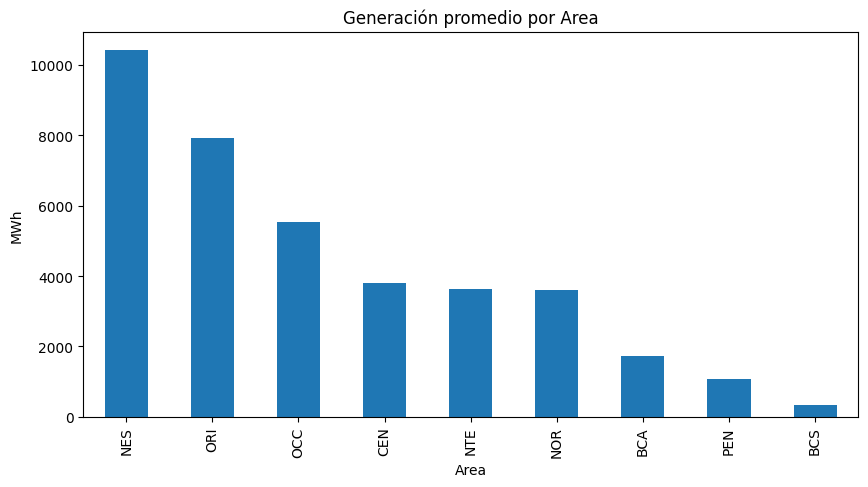

In [37]:
gen_area = df.groupby("Area")["Generacion (MWh)"].mean().sort_values(ascending=False)

gen_area.plot(kind="bar", figsize=(10,5))
plt.title("Generación promedio por Area")
plt.ylabel("MWh")
plt.show()